# IoT Sensor *Data* Analysis using Machine Learning
This notebook covers:
1. Data generation & preprocessing
2. Regression with a Dense Neural Network
3. Regression with an LSTM
4. Classification with an LSTM + Confusion Matrix


## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print('TensorFlow version:', tf.__version__)
np.random.seed(42)
tf.random.set_seed(42)


TensorFlow version: 2.19.0


## 2. Data Generation & Preprocessing

In [2]:
# ── Simulate IoT sensor data (replace with your actual data source) ──
N = 1000
iot_data = pd.DataFrame({
    'timestamp': pd.date_range(start='2024-01-01', periods=N, freq='H'),
    'temperature': np.random.normal(25, 5, N),
    'humidity': np.random.normal(50, 10, N),
})

# Time-based features
iot_data['hour']        = iot_data['timestamp'].dt.hour
iot_data['day_of_week'] = iot_data['timestamp'].dt.dayofweek

# Classification label: discretise temperature
def categorize_temp(temp: float) -> str:
    if temp < 20:  return 'Cold'
    if temp < 30:  return 'Moderate'
    return 'Hot'

iot_data['temp_category'] = iot_data['temperature'].apply(categorize_temp)
CATEGORY_MAP = {'Cold': 0, 'Moderate': 1, 'Hot': 2}

/tmp/ipykernel_18401/3566702797.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  'timestamp': pd.date_range(start='2024-01-01', periods=N, freq='H'),


In [3]:
print(iot_data.head())

            timestamp  temperature   humidity  hour  day_of_week temp_category
0 2024-01-01 00:00:00    27.483571  63.993554     0            0      Moderate
1 2024-01-01 01:00:00    24.308678  59.246337     1            0      Moderate
2 2024-01-01 02:00:00    28.238443  50.596304     2            0      Moderate
3 2024-01-01 03:00:00    32.615149  43.530632     3            0           Hot
4 2024-01-01 04:00:00    23.829233  56.982233     4            0      Moderate


In [4]:
print('\nClass distribution:\n', iot_data['temp_category'].value_counts())


Class distribution:
 temp_category
Moderate    698
Hot         155
Cold        147
Name: count, dtype: int64


In [5]:
print('\nBasic stats:\n', iot_data[['temperature','humidity']].describe())


Basic stats:
        temperature     humidity
count  1000.000000  1000.000000
mean     25.096660    50.708362
std       4.896080     9.974544
min       8.793663    20.596114
25%      21.762048    43.937583
50%      25.126503    50.630771
75%      28.239719    57.288822
max      44.263657    81.931076


## 3. Exploratory Data Analysis
Quick look at the distributions and correlations.

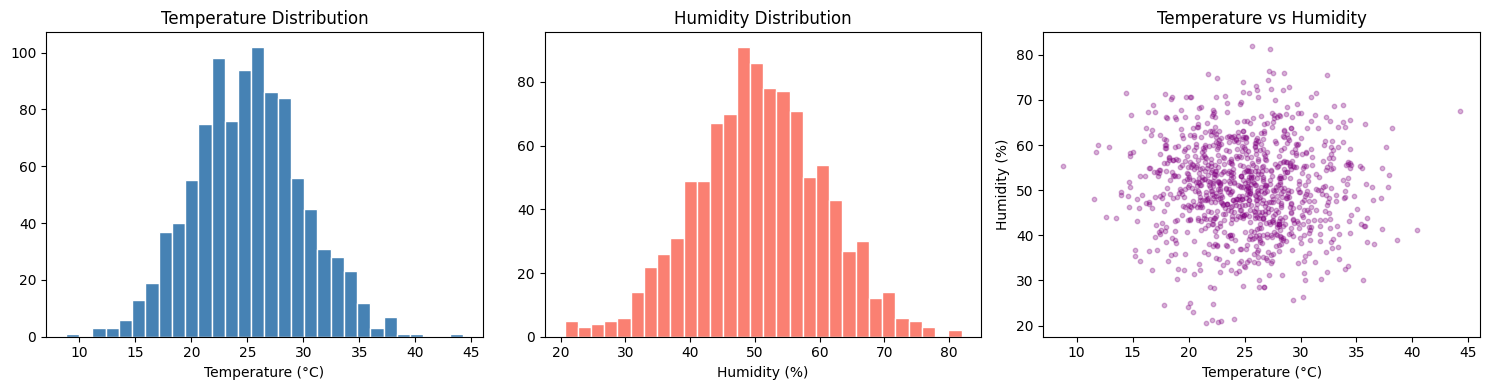

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(iot_data['temperature'], bins=30, color='steelblue',
             edgecolor='white')
axes[0].set_title('Temperature Distribution')
axes[0].set_xlabel('Temperature (°C)')

axes[1].hist(iot_data['humidity'], bins=30, color='salmon', edgecolor='white')
axes[1].set_title('Humidity Distribution')
axes[1].set_xlabel('Humidity (%)')

axes[2].scatter(iot_data['temperature'], iot_data['humidity'],
                alpha=0.3, s=10, color='purple')
axes[2].set_title('Temperature vs Humidity')
axes[2].set_xlabel('Temperature (°C)')
axes[2].set_ylabel('Humidity (%)')
plt.tight_layout()
plt.show()

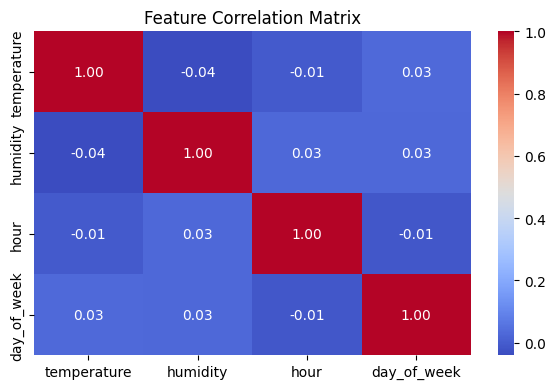

In [7]:
# Correlation heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(iot_data[['temperature','humidity','hour','day_of_week']].corr(),
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 4. Feature Preparation Helpers
Define reusable functions so each model section stays concise.

In [8]:
FEATURES = ['temperature', 'humidity', 'hour', 'day_of_week']
TARGET_REG = 'temperature'   # regression
TARGET_CLF = 'temp_category' # classification

def get_regression_data(lstm: bool = False):
    """Return normalised (X_train, X_test, y_train, y_test) for regression."""
    X = iot_data[FEATURES].values.astype(float)
    y = iot_data[TARGET_REG].values
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    if lstm:
        X = X.reshape(X.shape[0], 1, X.shape[1])  # (samples, timesteps, features)
    return train_test_split(X, y, test_size=0.2, random_state=42), scaler

In [9]:
def get_classification_data():
    """Return normalised LSTM-ready data for classification."""
    X = iot_data[FEATURES].values.astype(float)
    y = np.array([CATEGORY_MAP[v] for v in iot_data[TARGET_CLF]])
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    X = X.reshape(X.shape[0], 1, X.shape[1])
    return train_test_split(X, y, test_size=0.2, random_state=42), scaler


In [10]:
def plot_training_history(history, title='Training History'):
    """Plot loss (and optionally accuracy) curves."""
    fig, axes = plt.subplots(1, len(history.history) // 2 or 1, figsize=(12, 4))
    if not isinstance(axes, np.ndarray):
        axes = [axes]
    keys = [k for k in history.history if not k.startswith('val_')]
    for ax, key in zip(axes, keys):
        ax.plot(history.history[key], label=f'Train {key}')
        val_key = f'val_{key}'
        if val_key in history.history:
            ax.plot(history.history[val_key], label=f'Val {key}')
        ax.set_title(f'{title} – {key}')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(key)
        ax.legend()
    plt.tight_layout()
    plt.show()

# Shared EarlyStopping callback
EARLY_STOP = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)


##🧠 5. Dense Neural Network – Regression
### What is a Dense (Fully-Connected) Network?
Every neuron in one layer is connected to every neuron in the next. It's the simplest neural network architecture — a good baseline before trying more complex models.

### Architecture
```
Input (4 features)
  → Dense(64, ReLU)  ← learns non-linear patterns
  → Dropout(0.2)     ← randomly drops 20% of neurons during training to prevent overfitting
  → Dense(64, ReLU)
  → Dense(1)         ← single output: predicted temperature
```

### Loss function
**MSE (Mean Squared Error)** — penalises large prediction errors more heavily than small ones.

> ⚠️ A Dense network treats each sample independently. It does not model the *order* of readings, which matters for time-series data. That's why we also try an LSTM.

In [11]:
(X_train, X_test, y_train, y_test), scaler = get_regression_data(lstm=False)

dense_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1)
], name='dense_regressor')

dense_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
dense_model.summary()

history_dense = dense_model.fit(
    X_train, y_train,
    epochs=50, batch_size=32, validation_split=0.2,
    callbacks=[EARLY_STOP], verbose=0
)

loss_dense, mae_dense = dense_model.evaluate(X_test, y_test, verbose=0)
print(f'Dense Regressor – Test MSE: {loss_dense:.4f} | MAE: {mae_dense:.4f}')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "dense_regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,545 (17.75 KB)

 Trainable params: 4,545 (17.75 KB)

 Non-trainable params: 0 (0.00 B)

Dense Regressor – Test MSE: 1.4398 | MAE: 0.9089


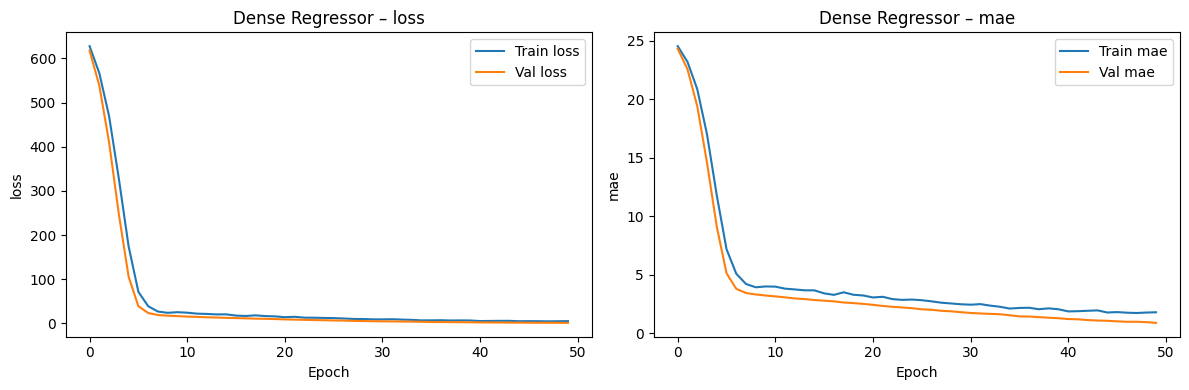

In [12]:
plot_training_history(history_dense, 'Dense Regressor')

## 6. LSTM – Regression
Same task as above but with an LSTM to capture sequential patterns.

In [13]:
(X_train, X_test, y_train, y_test), scaler = get_regression_data(lstm=True)

lstm_reg_model = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False),
    Dropout(0.2),
    Dense(1)
], name='lstm_regressor')

lstm_reg_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
lstm_reg_model.summary()

history_lstm_reg = lstm_reg_model.fit(
    X_train, y_train,
    epochs=50, batch_size=32, validation_split=0.2,
    callbacks=[EARLY_STOP], verbose=0
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "lstm_regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,729 (69.25 KB)

 Trainable params: 17,729 (69.25 KB)

 Non-trainable params: 0 (0.00 B)

LSTM Regressor – Test MSE: 642.5733 | MAE: 24.8838


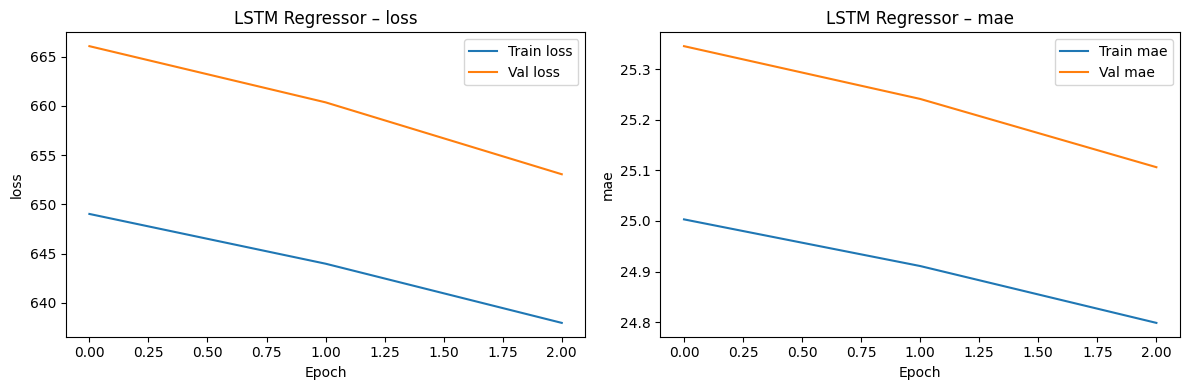

In [14]:
loss_lstm_reg, mae_lstm_reg = lstm_reg_model.evaluate(X_test, y_test, verbose=0)
print(f'LSTM Regressor – Test MSE: {loss_lstm_reg:.4f} | MAE: {mae_lstm_reg:.4f}')
plot_training_history(history_lstm_reg, 'LSTM Regressor')


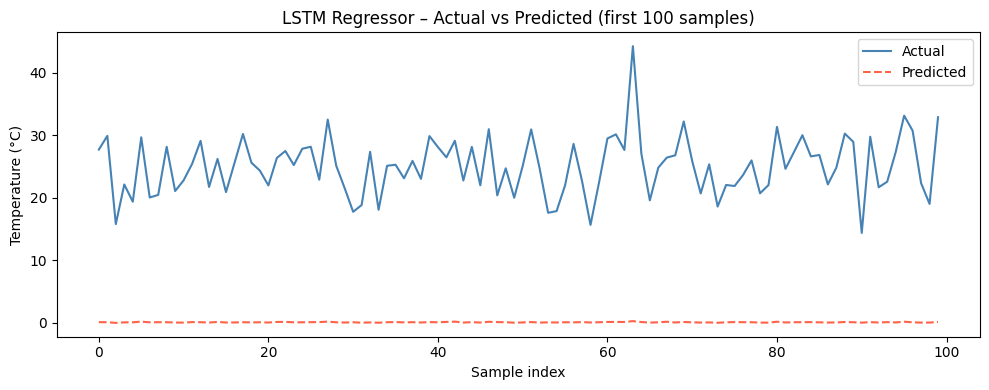

In [15]:
# Actual vs Predicted plot
y_pred_lstm = lstm_reg_model.predict(X_test, verbose=0).flatten()
plt.figure(figsize=(10, 4))
plt.plot(y_test[:100], label='Actual', color='steelblue')
plt.plot(y_pred_lstm[:100], label='Predicted', color='tomato', linestyle='--')
plt.title('LSTM Regressor – Actual vs Predicted (first 100 samples)')
plt.xlabel('Sample index')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()

## 7. LSTM – Classification
Classify each reading as Cold / Moderate / Hot.

In [16]:
(X_train, X_test, y_train, y_test), scaler = get_classification_data()

NUM_CLASSES = len(CATEGORY_MAP)

lstm_clf_model = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    Dense(NUM_CLASSES, activation='softmax')
], name='lstm_classifier')

lstm_clf_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
lstm_clf_model.summary()

history_clf = lstm_clf_model.fit(
    X_train, y_train,
    epochs=50, batch_size=32, validation_split=0.2,
    callbacks=[EARLY_STOP], verbose=0
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "lstm_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,859 (69.76 KB)

 Trainable params: 17,859 (69.76 KB)

 Non-trainable params: 0 (0.00 B)

LSTM Classifier – Test Loss: 0.0890 | Accuracy: 0.9750


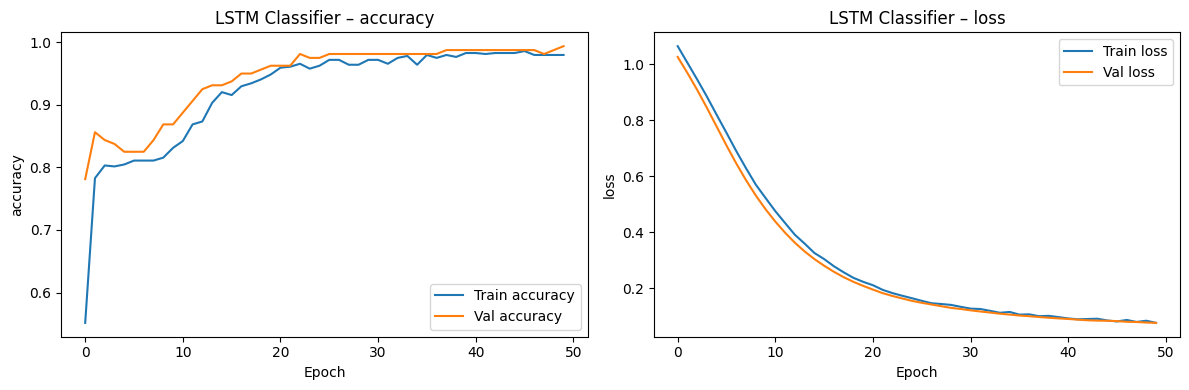

In [17]:
loss_clf, acc_clf = lstm_clf_model.evaluate(X_test, y_test, verbose=0)
print(f'LSTM Classifier – Test Loss: {loss_clf:.4f} | Accuracy: {acc_clf:.4f}')
plot_training_history(history_clf, 'LSTM Classifier')


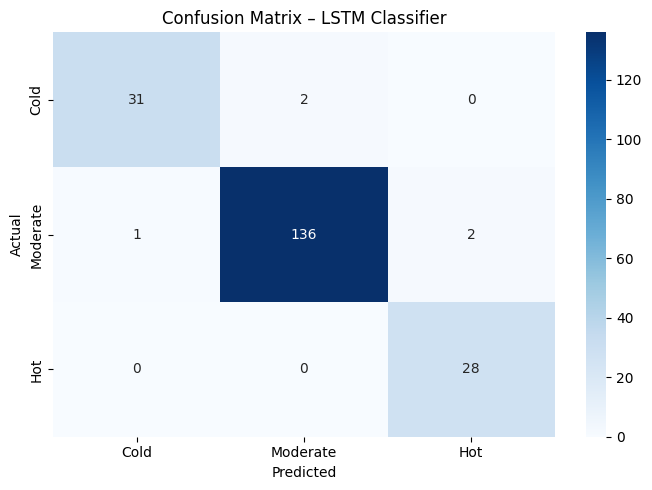

In [18]:
# Confusion matrix
y_pred_clf = np.argmax(lstm_clf_model.predict(X_test, verbose=0), axis=1)
labels = list(CATEGORY_MAP.keys())
cm = confusion_matrix(y_test, y_pred_clf)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix – LSTM Classifier')
plt.tight_layout()
plt.show()


In [19]:
print('\nClassification Report:')
print(classification_report(y_test, y_pred_clf, target_names=labels))


Classification Report:
              precision    recall  f1-score   support

        Cold       0.97      0.94      0.95        33
    Moderate       0.99      0.98      0.98       139
         Hot       0.93      1.00      0.97        28

    accuracy                           0.97       200
   macro avg       0.96      0.97      0.97       200
weighted avg       0.98      0.97      0.98       200



## 8. Model Comparison

This section provides a side-by-side summary of the performance metrics for all trained models. It allows for a quick comparison of the Dense Neural Network and LSTM models across both regression and classification tasks, highlighting their respective strengths and weaknesses in terms of Mean Squared Error (MSE), Mean Absolute Error (MAE), and Accuracy.

In [20]:
comparison = pd.DataFrame({
    'Model': ['Dense Regressor', 'LSTM Regressor', 'LSTM Classifier'],
    'Task': ['Regression', 'Regression', 'Classification'],
    'Test MSE / Loss': [round(loss_dense, 4), round(loss_lstm_reg, 4), round(loss_clf, 4)],
    'Test MAE / Accuracy': [round(mae_dense, 4), round(mae_lstm_reg, 4), round(acc_clf, 4)],
})
print(comparison.to_string(index=False))


          Model           Task  Test MSE / Loss  Test MAE / Accuracy
Dense Regressor     Regression           1.4398               0.9089
 LSTM Regressor     Regression         642.5733              24.8838
LSTM Classifier Classification           0.0890               0.9750


### Visualizing Model Comparison

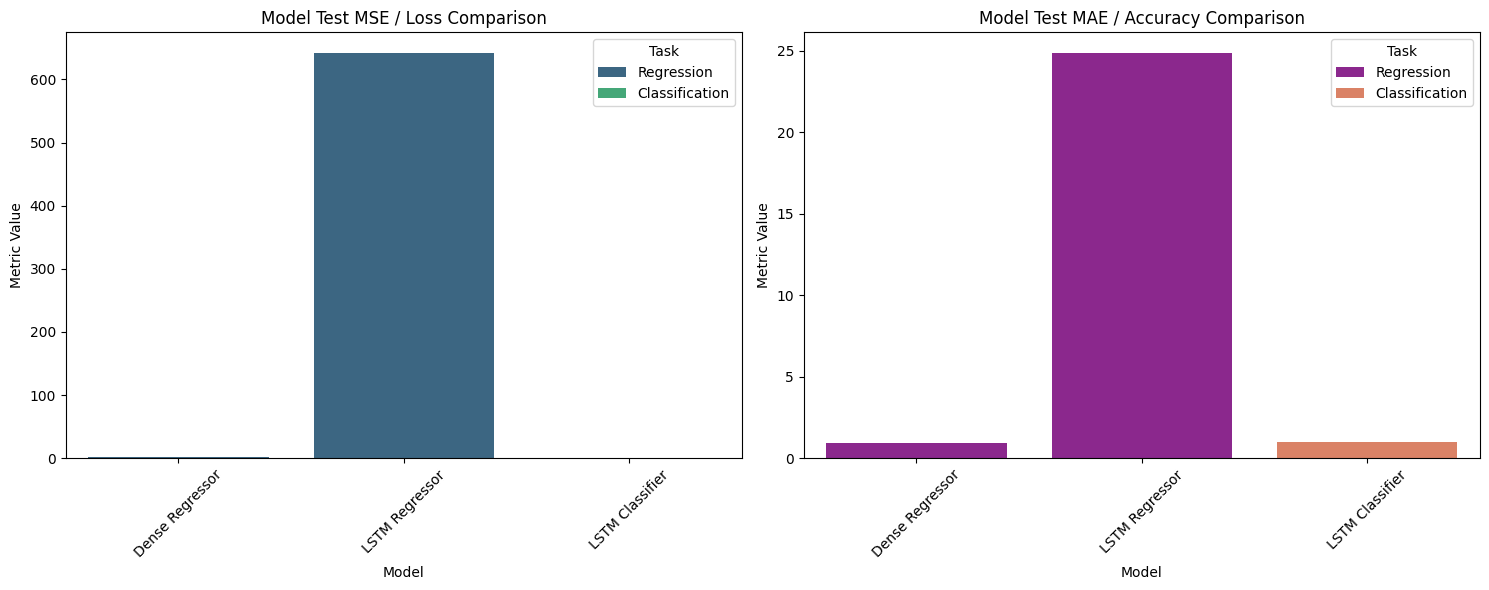

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(x='Model', y='Test MSE / Loss', hue='Task', data=comparison, palette='viridis', ax=axes[0])
axes[0].set_title('Model Test MSE / Loss Comparison')
axes[0].set_ylabel('Metric Value')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Task')

sns.barplot(x='Model', y='Test MAE / Accuracy', hue='Task', data=comparison, palette='plasma', ax=axes[1])
axes[1].set_title('Model Test MAE / Accuracy Comparison')
axes[1].set_ylabel('Metric Value')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Task')

plt.tight_layout()
plt.show()